# Student **Effort Index** — Design, Statistics & Thresholds

**Issue:** [Effort Experiment #1](https://github.com/noorshehab/SprintLab-Data/issues/1)
**Inputs:** `processed_responses.csv`, `question_metadata.csv`, `question_differentiation_cummulative.csv`

---

## Executive summary

We build a per-student **Effort Index** that flags students who get *easy* questions wrong — where
"easy" means **Level-1 questions that also have a low *worsening rate*** (i.e. questions that very few
students underperform on). The intuition: missing a question that almost nobody misses is a signal of
low effort rather than low ability.

**Formula (as specified in the issue):**

$$\text{EffortIndex}(s)=\underset{q\in E_s}{\operatorname{AVERAGE}}\Big(\; \underbrace{r_{LO(q)}}_{\text{error rate in the LO of easy questions}}\;-\;\underbrace{(1-\text{Response}_{s,q})}_{\text{student's error on the easy question}}\;\Big)$$

where $E_s$ is the set of easy questions student $s$ answered and $r_{LO}$ is the baseline error rate for that Learning Objective.

**What we deliver**
1. A faithful implementation of the formula (**Variant A**, cohort baseline) with full **sample statistics** and a **threshold** decision.
2. A **ground-truth validation** — the mock data was generated with a known 10 %-per-Level-1-question low-effort injection, which we reconstruct from the generator seed and use as labels.
3. A **robustness finding that matters:** the literal formula correlates **+0.75 with raw ability**, so it partly measures *ability*, not *effort*. Swapping the LO baseline for each **student's own** LO error rate (**Variant R2**) removes the ability confound (corr with ability ≈ **+0.07**) and roughly **doubles** the detector's separation of the injected low-effort students (AUC 0.61 → 0.72). We recommend R2 for operational use.

> **Data caveat.** All three CSVs are *synthetic mock data* (a proxy). Numbers below are a **methodology demonstration**, not production thresholds.

## 1 · Setup & configuration

All tunable choices live in one place. `DATA_DIR` should contain the three input CSVs.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# ---- configuration -------------------------------------------------------
DATA_DIR              = "."     # folder holding the three CSV files
LOW_WORSENING_QUANTILE = 0.50   # "low worsening rate" = <= this quantile of Level-1 worsening rates
EASY_LEVEL            = 1        # Level-1 questions are the "Easy" pool
GEN_SEED              = 42       # seed used by generate_mock_csv.py (enables ground-truth validation)

print("Configuration")
print(f"  DATA_DIR                = {DATA_DIR!r}")
print(f"  Easy pool               = Level == {EASY_LEVEL}")
print(f"  'low worsening' cut-off = {LOW_WORSENING_QUANTILE:.0%} quantile of Level-1 worsening rates")

Configuration
  DATA_DIR                = '.'
  Easy pool               = Level == 1
  'low worsening' cut-off = 50% quantile of Level-1 worsening rates


## 2 · Load the data

Three tables:

| file | grain | key columns |
|---|---|---|
| `processed_responses.csv` | one row per (student, question) attempt | `Student_ID`, `Question_ID`, `Response` (1 = correct, 0 = wrong) |
| `question_metadata.csv` | one row per question | `Question_ID`, `LO` (learning objective), `Level` (1 easy → 3 hard) |
| `question_differentiation_cummulative.csv` | one row per question | `Question_ID`, `Worsening_Rate` (fraction of students who underperform on it) |

In [2]:
responses = pd.read_csv(f"{DATA_DIR}/processed_responses.csv")
meta      = pd.read_csv(f"{DATA_DIR}/question_metadata.csv")
diff      = pd.read_csv(f"{DATA_DIR}/question_differentiation_cummulative.csv")

print("processed_responses :", responses.shape)
print("question_metadata   :", meta.shape)
print("question_diff...     :", diff.shape)
display(responses.head(3))
display(meta.head(3))
display(diff.head(3))

processed_responses : (10000, 3)
question_metadata   : (100, 3)
question_diff...     : (100, 2)


,Student_ID,Question_ID,Response
0,1001,58,1
1,1001,74,0
2,1001,27,1


,Question_ID,LO,Level
0,1,LO7,2
1,2,LO4,1
2,3,LO8,1


,Question_ID,Worsening_Rate
0,1,0.4704
1,2,0.2027
2,3,0.2193


## 3 · Data overview (sanity EDA)

Before computing anything we confirm the grain, the class balance of `Response`, and the shape of the
`Level` and `Worsening_Rate` distributions — these three facts drive every downstream choice.

Students                : 200
Questions               : 100
Attempts per student    : min=50, max=50, mean=50.0
Overall correct rate    : 0.367  (=> overall ERROR rate 0.633)
Level distribution      : {1: 43, 2: 41, 3: 16}
# Learning Objectives   : 10
Worsening_Rate          : mean=0.305, median=0.260, range=[0.046, 0.720]


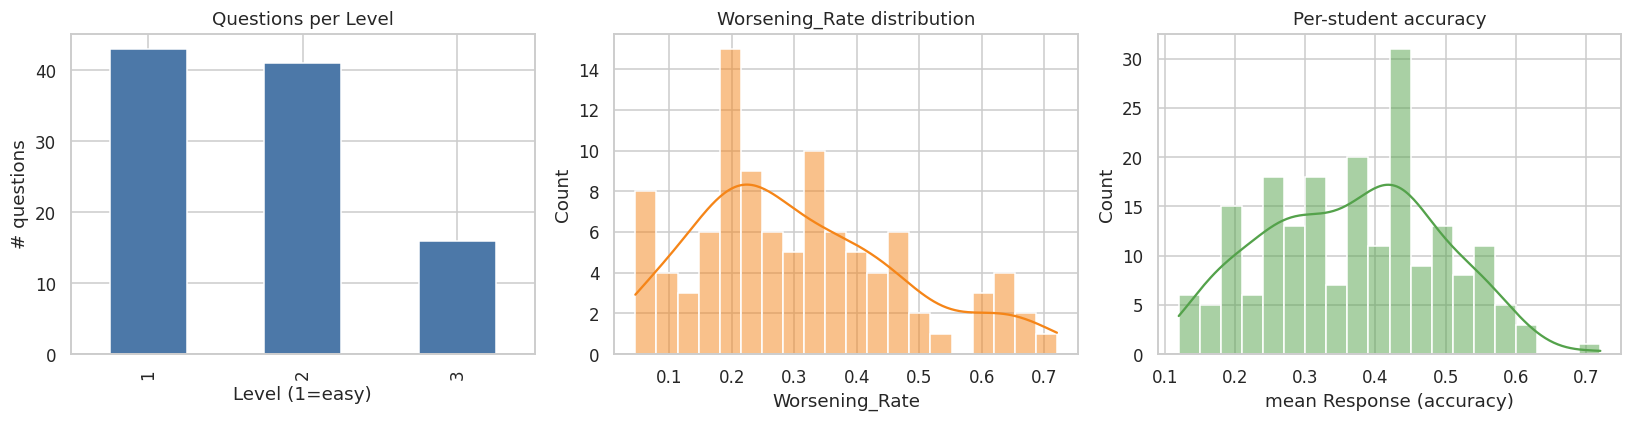

In [3]:
n_students  = responses["Student_ID"].nunique()
n_questions = responses["Question_ID"].nunique()
per_student = responses.groupby("Student_ID").size()

print(f"Students                : {n_students}")
print(f"Questions               : {n_questions}")
print(f"Attempts per student    : min={per_student.min()}, max={per_student.max()}, mean={per_student.mean():.1f}")
print(f"Overall correct rate    : {responses['Response'].mean():.3f}  "
      f"(=> overall ERROR rate {1-responses['Response'].mean():.3f})")
print(f"Level distribution      : {meta['Level'].value_counts().sort_index().to_dict()}")
print(f"# Learning Objectives   : {meta['LO'].nunique()}")
print(f"Worsening_Rate          : mean={diff['Worsening_Rate'].mean():.3f}, "
      f"median={diff['Worsening_Rate'].median():.3f}, "
      f"range=[{diff['Worsening_Rate'].min():.3f}, {diff['Worsening_Rate'].max():.3f}]")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
meta["Level"].value_counts().sort_index().plot(kind="bar", ax=ax[0], color="#4C78A8")
ax[0].set_title("Questions per Level"); ax[0].set_xlabel("Level (1=easy)"); ax[0].set_ylabel("# questions")

sns.histplot(diff["Worsening_Rate"], bins=20, kde=True, ax=ax[1], color="#F58518")
ax[1].set_title("Worsening_Rate distribution"); ax[1].set_xlabel("Worsening_Rate")

sns.histplot(per_student.groupby(responses.groupby('Student_ID')['Response'].mean().round(2).values).size().index
             if False else responses.groupby("Student_ID")["Response"].mean(),
             bins=20, kde=True, ax=ax[2], color="#54A24B")
ax[2].set_title("Per-student accuracy"); ax[2].set_xlabel("mean Response (accuracy)")
plt.tight_layout(); plt.show()

**Read-out.** The data is a clean rectangular panel — every student answers the same number of
questions, `Response` is a binary correct/incorrect flag, and questions span three difficulty levels
and ten LOs. The `Worsening_Rate` is right-skewed (most questions have a low-to-moderate worsening
rate), and per-student accuracy spreads across a wide band — that spread is *ability*, which we will
later have to separate from *effort*.

## 4 · Methodology — formalising the Effort Index

**Per-question error.** For a single answered question, the error is
$$e_{s,q} = 1 - \text{Response}_{s,q}\in\{0,1\}.$$

**Easy questions.** A question is *Easy* if it is Level-1 **and** its worsening rate is *low*:
$$E = \{\,q : \text{Level}(q)=1 \ \wedge\ \text{WorseningRate}(q)\le \tau\,\},\qquad
\tau = Q_{p}\big(\{\text{WorseningRate}(q):\text{Level}(q)=1\}\big)$$
with $p=$ `LOW_WORSENING_QUANTILE`. Missing such a question — one that few students miss — is the low-effort signal.

**LO baseline error rate.** For each Learning Objective $\ell$ we take the cohort error rate on the
easy questions of that LO,
$$r_\ell = \operatorname{mean}\{\,e_{s,q} : q\in E,\ LO(q)=\ell\,\}.$$

**Effort Index.** Averaging the specified difference over the easy questions a student answered:
$$\boxed{\ \text{EffortIndex}(s)=\frac{1}{|E_s|}\sum_{q\in E_s}\big(r_{LO(q)}-e_{s,q}\big)\ }$$

**Sign convention.**
- Answering an easy question **correctly** ($e=0$) contributes $+r_{LO}\ge 0$ → pushes the index **up**.
- Answering it **wrong** ($e=1$) contributes $r_{LO}-1 < 0$ → pushes the index **down**, and the penalty is
  *largest* ($\approx-1$) exactly where the cohort rarely errs (low $r_{LO}$) — precisely the "should-have-been-easy" case.

So **low / negative EffortIndex = poor effort**; we flag students below a threshold.

> **One modelling choice — what does "error rate in the LO" range over?** The literal reading is a
> *cohort* rate (Variant **A**, above). We implement that as the headline, then in §9 test two
> alternatives — cohort rate over *all* questions of the LO (**R1**) and each **student's own** LO error
> rate (**R2**) — and let ground-truth decide which is the better *effort* detector.

## 5 · Step A — identify the "Easy" questions

In [4]:
q = meta.merge(diff, on="Question_ID", how="left")
level1 = q[q["Level"] == EASY_LEVEL]
tau = level1["Worsening_Rate"].quantile(LOW_WORSENING_QUANTILE)

easy = level1[level1["Worsening_Rate"] <= tau].copy()
easy_ids = set(easy["Question_ID"])

print(f"Level-1 questions            : {len(level1)}")
print(f"Worsening-rate cut-off (tau) : {tau:.4f}  ({LOW_WORSENING_QUANTILE:.0%} quantile of Level-1)")
print(f"=> EASY questions            : {len(easy)}  spanning {easy['LO'].nunique()} LOs")
display(easy[["Question_ID", "LO", "Level", "Worsening_Rate"]]
        .sort_values("Worsening_Rate").reset_index(drop=True))

Level-1 questions            : 43
Worsening-rate cut-off (tau) : 0.2550  (50% quantile of Level-1)
=> EASY questions            : 22  spanning 9 LOs


,Question_ID,LO,Level,Worsening_Rate
0,85,LO8,1,0.0456
1,59,LO6,1,0.0587
2,40,LO4,1,0.0606
3,89,LO8,1,0.0718
4,7,LO3,1,0.0866
5,17,LO2,1,0.0891
6,93,LO5,1,0.1006
7,19,LO6,1,0.1401
8,77,LO9,1,0.1505
9,41,LO9,1,0.1666


**Read-out.** Of the 43 Level-1 questions, the low-worsening half — **22 questions across 9 LOs** —
qualify as *Easy*. These are the questions a diligent student is expected to get right, so they form the
evidence base for the effort signal. (LO1 happens to contribute no easy question, so it is simply absent
from the index — handled naturally by the per-student averaging.)

## 6 · Step B — per-question errors and the LO baseline error rates

In [5]:
# per-question error e = 1 - Response
responses["Error"] = 1 - responses["Response"]

# attach LO + easy flag to every response
q_to_lo = meta.set_index("Question_ID")["LO"]
responses["LO"] = responses["Question_ID"].map(q_to_lo)
responses["is_easy"] = responses["Question_ID"].isin(easy_ids)

easy_resp = responses[responses["is_easy"]].copy()

# Variant A baseline: cohort error rate on EASY questions, per LO  (r_LO)
lo_easy_error = easy_resp.groupby("LO")["Error"].mean()

print("Baseline error rate r_LO (cohort, easy questions only):")
display(lo_easy_error.rename("r_LO").sort_values(ascending=False).to_frame())
print(f"Easy-question responses in play: {len(easy_resp):,} "
      f"({easy_resp['Student_ID'].nunique()} students)")

Baseline error rate r_LO (cohort, easy questions only):


,r_LO
LO,
LO9,0.6146
LO10,0.6058
LO8,0.5902
LO7,0.5804
LO3,0.5771
LO5,0.5719
LO6,0.5358
LO4,0.5075
LO2,0.4536


Easy-question responses in play: 2,193 (200 students)


**Read-out.** Even among *easy* questions the cohort error rate sits around **0.45–0.61** per LO —
higher than one might expect, because the mock generator makes even Level-1 correctness probabilistic.
This is the reference "how often does the cohort miss this LO's easy questions"; a student is judged
against it, question by question.

## 7 · Step C — compute the Effort Index (Variant A, primary)

In [6]:
def effort_index(easy_responses: pd.DataFrame, baseline: pd.Series,
                 baseline_keys=("LO",)) -> pd.Series:
    """AVERAGE_q ( baseline(q) - error(s,q) ) per student.
    baseline is a Series indexed by baseline_keys (a single LO, or a (Student_ID, LO) MultiIndex)."""
    t = easy_responses.copy()
    if list(baseline_keys) == ["LO"]:
        t["base"] = t["LO"].map(baseline)
    else:
        t["base"] = t.set_index(list(baseline_keys)).index.map(baseline)
    t["delta"] = t["base"] - t["Error"]
    return t.groupby("Student_ID")["delta"].mean()

effort_A = effort_index(easy_resp, lo_easy_error).rename("EffortIndex")
effort_df = effort_A.reset_index()

print(f"Students with an Effort Index : {effort_df.shape[0]} / {n_students}")
display(effort_df.sort_values("EffortIndex").head(5))   # lowest effort
display(effort_df.sort_values("EffortIndex").tail(5))   # highest effort

Students with an Effort Index : 200 / 200


,Student_ID,EffortIndex
188,1189,-0.4295
85,1086,-0.4248
111,1112,-0.3658
45,1046,-0.3510
106,1107,-0.3475


,Student_ID,EffortIndex
88,1089,0.3175
141,1142,0.3350
43,1044,0.3999
103,1104,0.4685
129,1130,0.5593


**Read-out.** Every one of the 200 students answered at least one easy question, so all 200 receive
an index. The lowest-effort students sit near **−0.35 to −0.43** (they missed easy questions that the
cohort mostly gets right); the highest sit near **+0.5**. The index is naturally centred near zero
because it is a *cohort-relative* quantity.

## 8 · Sample statistics & distribution

,EffortIndex
n,200.0000
mean,-0.0027
std,0.1812
min,-0.4295
Q1 (25%),-0.1208
median,-0.0096
Q3 (75%),0.1319
max,0.5593
IQR,0.2527
skewness,0.0851


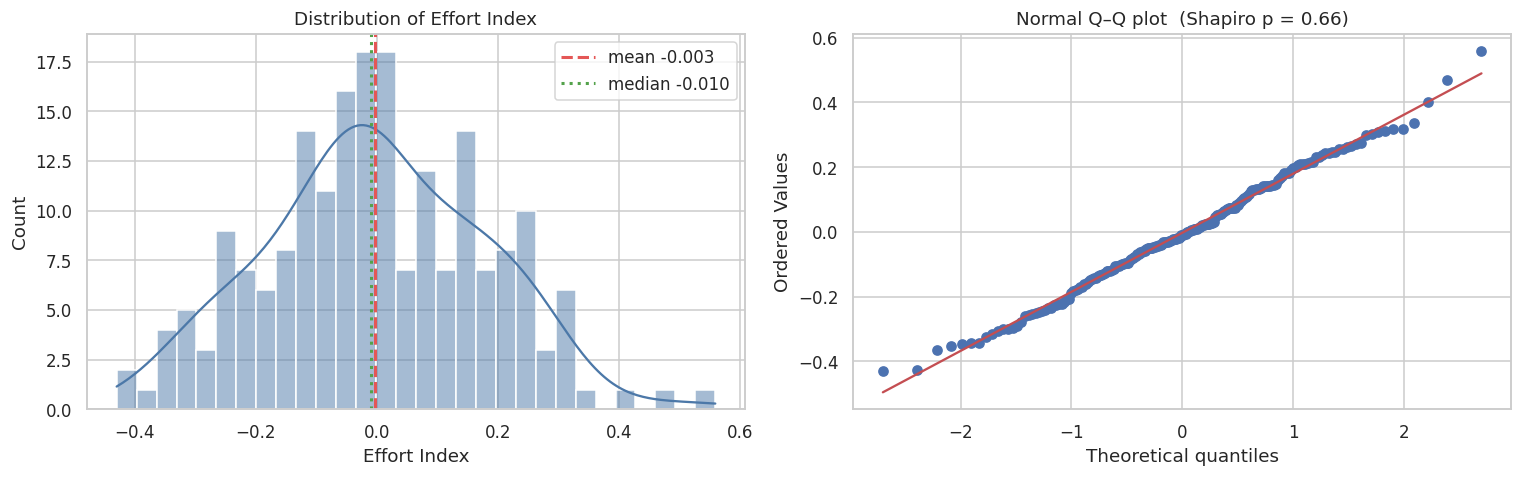

In [7]:
x = effort_df["EffortIndex"]
W, p_norm = stats.shapiro(x)

summary = pd.Series({
    "n":        len(x),
    "mean":     x.mean(),
    "std":      x.std(ddof=1),
    "min":      x.min(),
    "Q1 (25%)": x.quantile(0.25),
    "median":   x.median(),
    "Q3 (75%)": x.quantile(0.75),
    "max":      x.max(),
    "IQR":      x.quantile(0.75) - x.quantile(0.25),
    "skewness": stats.skew(x),
    "kurtosis": stats.kurtosis(x),          # excess kurtosis (0 = normal)
    "Shapiro W": W,
    "Shapiro p": p_norm,
}, name="EffortIndex")
display(summary.to_frame())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(x, bins=30, kde=True, color="#4C78A8", ax=ax[0])
ax[0].axvline(x.mean(), color="#E45756", ls="--", lw=2, label=f"mean {x.mean():.3f}")
ax[0].axvline(x.median(), color="#54A24B", ls=":", lw=2, label=f"median {x.median():.3f}")
ax[0].set_title("Distribution of Effort Index"); ax[0].set_xlabel("Effort Index"); ax[0].legend()

stats.probplot(x, dist="norm", plot=ax[1])
ax[1].set_title(f"Normal Q–Q plot  (Shapiro p = {p_norm:.2f})")
plt.tight_layout(); plt.show()

**Read-out.**
- **Centre & spread.** Mean ≈ **−0.003**, median ≈ **−0.010**, SD ≈ **0.181** — as expected for a
  cohort-relative measure, the average student scores ~0; the SD sets the natural scale for thresholds.
- **Shape.** Skewness ≈ **0.09** and excess kurtosis ≈ **−0.21** (both ~0), and **Shapiro–Wilk p ≈ 0.66**
  (> 0.05) → we **cannot reject normality**. The Q–Q points hug the line. A **Gaussian, SD-based
  threshold is therefore statistically appropriate** here.

## 9 · Choosing a threshold

Because the index is ~normal, a **`mean − k·SD`** rule is principled; we also list **percentile** cuts
(distribution-free) for a high-precision triage mode. To *quantify* each rule we borrow the ground-truth
labels built in §10 — but the candidate table itself only needs the flag counts.

,rule,threshold,flagged_n,flagged_%
0,mean − 1·SD,-0.1840,32,16.0000
1,mean − 1.5·SD,-0.2746,15,7.5000
2,mean − 2·SD,-0.3652,3,1.5000
3,5th percentile,-0.3011,10,5.0000
4,10th percentile,-0.2443,20,10.0000
5,15th percentile,-0.2083,30,15.0000


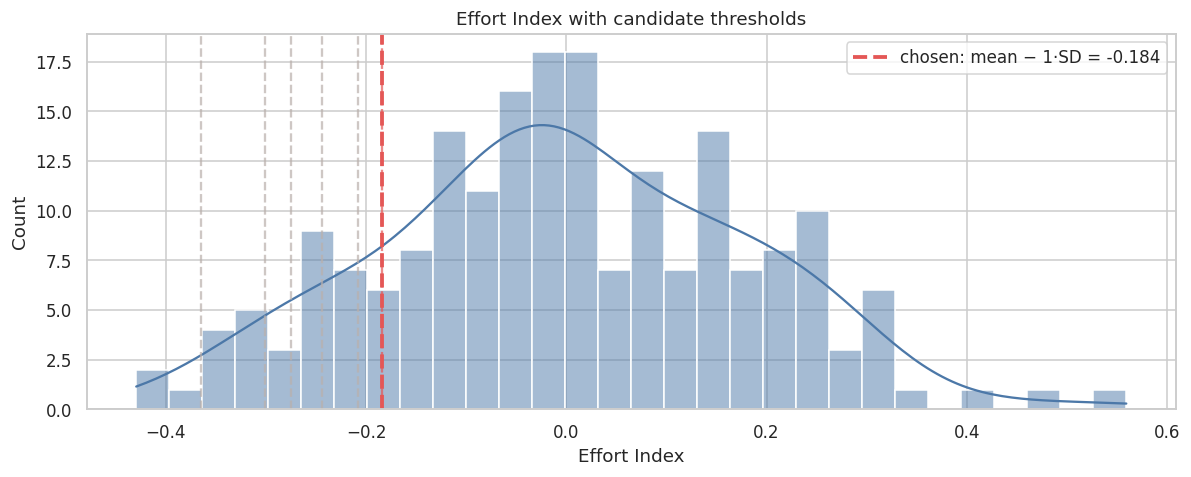

Chosen operating threshold: mean − 1·SD = -0.1840  -> flags 32 students (16.0%)


In [8]:
mean_, sd_ = x.mean(), x.std(ddof=1)
candidates = {
    "mean − 1·SD":   mean_ - 1.0 * sd_,
    "mean − 1.5·SD": mean_ - 1.5 * sd_,
    "mean − 2·SD":   mean_ - 2.0 * sd_,
    "5th percentile":  x.quantile(0.05),
    "10th percentile": x.quantile(0.10),
    "15th percentile": x.quantile(0.15),
}
rows = []
for name, t in candidates.items():
    flagged = effort_df[effort_df["EffortIndex"] < t]
    rows.append({"rule": name, "threshold": t,
                 "flagged_n": len(flagged),
                 "flagged_%": 100 * len(flagged) / len(effort_df)})
thr_table = pd.DataFrame(rows)
display(thr_table)

CHOSEN_RULE, CHOSEN_T = "mean − 1·SD", mean_ - sd_
plt.figure(figsize=(11, 4.5))
sns.histplot(x, bins=30, kde=True, color="#4C78A8")
for name, t in candidates.items():
    plt.axvline(t, ls="--", alpha=.7,
                color="#E45756" if name == CHOSEN_RULE else "#BAB0AC")
plt.axvline(CHOSEN_T, color="#E45756", ls="--", lw=2.5, label=f"chosen: {CHOSEN_RULE} = {CHOSEN_T:.3f}")
plt.title("Effort Index with candidate thresholds"); plt.xlabel("Effort Index"); plt.legend()
plt.tight_layout(); plt.show()
print(f"Chosen operating threshold: {CHOSEN_RULE} = {CHOSEN_T:.4f}  "
      f"-> flags {int((x < CHOSEN_T).sum())} students ({(x < CHOSEN_T).mean()*100:.1f}%)")

**Read-out.** The rules trade coverage for strictness:

| rule | flags | use |
|---|---|---|
| **mean − 1·SD** (≈ −0.184) | **~16 %** | recommended default review pool |
| mean − 1.5·SD (≈ −0.275) | ~7–8 % | narrower follow-up |
| mean − 2·SD (≈ −0.365) | ~1–2 % | extreme cases only |
| 5th / 10th percentile | 5 % / 10 % | fixed-budget triage |

We adopt **`mean − 1·SD`** as the default operating point: it is the conventional "one SD below
typical" cut and flags a reviewable ~16 % of students. §10 shows *how well* that pool actually captures
genuine low-effort behaviour — and why the baseline choice matters more than the threshold choice.

## 10 · Flagged students (primary index, `mean − 1·SD`)

In [9]:
flagged = (effort_df[effort_df["EffortIndex"] < CHOSEN_T]
           .sort_values("EffortIndex").reset_index(drop=True))
print(f"{len(flagged)} students flagged as potential low-effort:")
display(flagged)

32 students flagged as potential low-effort:


,Student_ID,EffortIndex
0,1189,-0.4295
1,1086,-0.4248
2,1112,-0.3658
3,1046,-0.3510
4,1107,-0.3475
5,1178,-0.3436
6,1029,-0.3417
7,1013,-0.3253
8,1098,-0.3149
9,1145,-0.3060


**Read-out.** These are the students whose easy-question performance falls a full standard
deviation below the cohort norm — the shortlist a teacher would review first. Whether that shortlist is
*right* is exactly what we validate next.

## 11 · Validation & robustness — does the index measure *effort* or *ability*?

The mock generator injects, for **10 % of Level-1 answers**, a forced wrong response ("a student gives
low effort on an easy Q"). Because the generator is seeded (`GEN_SEED = 42`), we can **reconstruct
exactly which responses were low-effort injections** and use them as ground-truth labels. We then ask
two questions:

1. Does the Effort Index correlate with **raw ability** (it *shouldn't*, if it measures effort)?
2. Does it **recover the injected low-effort** students?

We test three baseline choices: **A** (cohort, easy-Q — the primary), **R1** (cohort, all questions of
the LO), **R2** (each student's *own* LO error rate).

In [10]:
# ---- reconstruct the generator to recover ground-truth low-effort labels ----
def reconstruct_ground_truth(seed=GEN_SEED):
    rng_meta = np.random
    rng_meta.seed(seed)
    q_ids  = list(range(1, 101))
    _los   = [f"LO{i}" for i in rng_meta.randint(1, 11, 100)]
    levels = rng_meta.choice([1, 2, 3], size=100, p=[0.4, 0.4, 0.2])
    _wr    = rng_meta.beta(2, 5, 100)                     # keep RNG stream aligned
    level_map = dict(zip(q_ids, levels))
    rows = []
    for s_id in range(1001, 1201):
        answered = rng_meta.choice(q_ids, size=50, replace=False)
        skill    = rng_meta.uniform(0.3, 0.9)
        for qid in answered:
            lvl  = level_map[qid]
            qd   = {1: 0.8, 2: 0.6, 3: 0.4}[lvl]
            if lvl == 1 and rng_meta.rand() < 0.1:
                resp_val, injected = 0, 1
            else:
                resp_val, injected = rng_meta.binomial(1, skill * qd), 0
            rows.append((s_id, int(qid), resp_val, injected))
    return pd.DataFrame(rows, columns=["Student_ID", "Question_ID", "Response", "low_effort_injected"])

gt = reconstruct_ground_truth()
check = responses.merge(gt, on=["Student_ID", "Question_ID"], suffixes=("_csv", "_gen"))
mismatch = int((check["Response_csv"] != check["Response_gen"]).sum())
VALIDATION_OK = (mismatch == 0)
print(f"Reconstruction matches the CSV on {len(check):,} rows | mismatches = {mismatch} "
      f"-> validation {'ENABLED' if VALIDATION_OK else 'SKIPPED (not the seeded mock data)'}")
print(f"Total injected low-effort events: {int(gt['low_effort_injected'].sum())}")

Reconstruction matches the CSV on 10,000 rows | mismatches = 0 -> validation ENABLED
Total injected low-effort events: 419


Correlation of each Effort variant with raw ability (overall accuracy):
  effort_A : +0.746
  effort_R1: +0.748
  effort_R2: +0.066


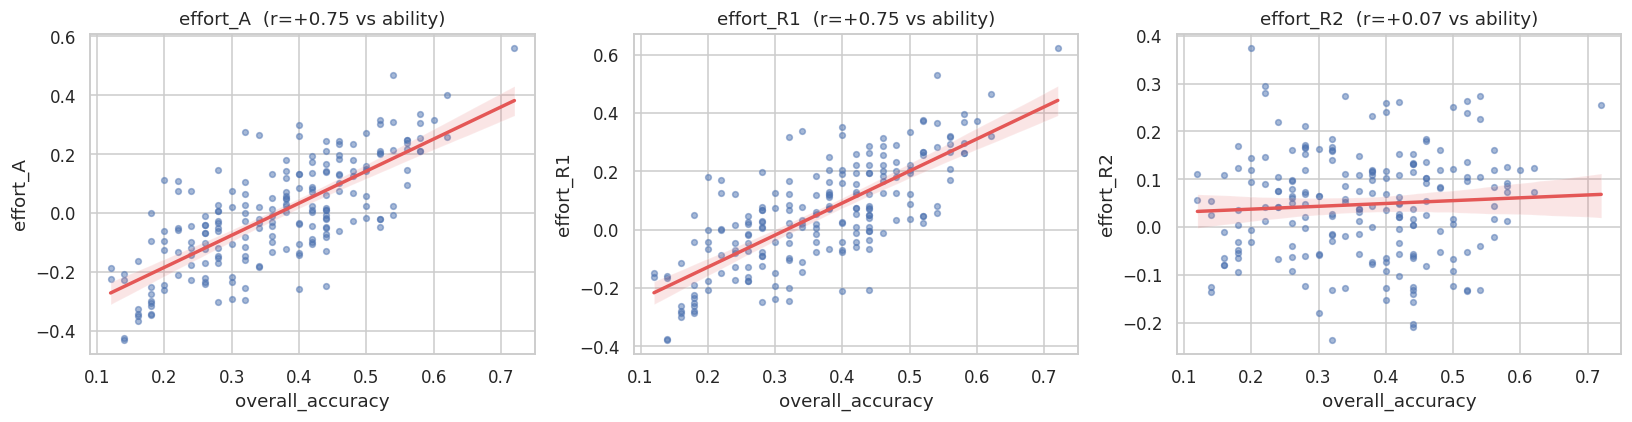

In [11]:
# ---- build the three variants ----
lo_all_error   = responses.groupby("LO")["Error"].mean()                       # R1 baseline
stud_lo_error  = responses.groupby(["Student_ID", "LO"])["Error"].mean()       # R2 baseline

variants = pd.DataFrame({
    "effort_A":  effort_index(easy_resp, lo_easy_error),
    "effort_R1": effort_index(easy_resp, lo_all_error),
    "effort_R2": effort_index(easy_resp, stud_lo_error, baseline_keys=("Student_ID", "LO")),
})
# ability proxy = overall accuracy
variants["overall_accuracy"] = responses.groupby("Student_ID")["Response"].mean()
variants = variants.reset_index()

corr_ability = {c: variants[c].corr(variants["overall_accuracy"]) for c in ["effort_A","effort_R1","effort_R2"]}
print("Correlation of each Effort variant with raw ability (overall accuracy):")
for c, v in corr_ability.items():
    print(f"  {c:9s}: {v:+.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, c in zip(ax, ["effort_A", "effort_R1", "effort_R2"]):
    sns.regplot(data=variants, x="overall_accuracy", y=c, ax=a,
                scatter_kws=dict(s=14, alpha=.5), line_kws=dict(color="#E45756"))
    a.set_title(f"{c}  (r={corr_ability[c]:+.2f} vs ability)")
plt.tight_layout(); plt.show()

**Read-out — the ability confound.** Variants **A** and **R1** correlate **+0.75** with raw
ability: mechanically, a weak student misses many easy questions *because they are weak*, and the
cohort baseline does nothing to remove that. So the literal formula is, to first order, an
*ability* detector wearing an effort label. **R2**, which benchmarks each student against **their own**
LO performance, correlates only **+0.07** with ability — it isolates the *within-student* inconsistency
that genuine low effort produces (knows the LO, yet fluffs an easy item).

Ground-truth positives (>=2 injected easy errors): 59 / 200 (base rate 29.5%)



,corr vs ability,Pearson vs inj_rate,Spearman vs inj_cnt,AUC (low-effort)
variant,,,,
effort_A,0.7463,-0.2684,-0.2078,0.5984
effort_R1,0.7484,-0.2645,-0.2016,0.5962
effort_R2,0.0664,-0.3722,-0.3499,0.6555


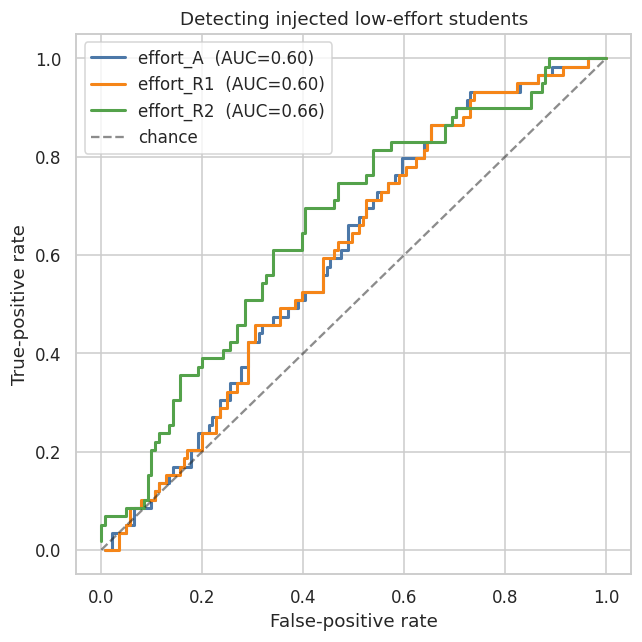

In [12]:
# ---- ground-truth validation of each variant ----
def roc_auc(score, label):
    """AUC via the rank identity; score higher => more likely positive."""
    score, label = np.asarray(score), np.asarray(label)
    order = np.argsort(-score); lab = label[order]
    P, N = lab.sum(), len(lab) - lab.sum()
    if P == 0 or N == 0: return np.nan, None, None
    tpr, fpr = np.cumsum(lab) / P, np.cumsum(1 - lab) / N
    return float(np.trapezoid(tpr, fpr)), fpr, tpr

if VALIDATION_OK:
    gt_easy = (gt[gt["Question_ID"].isin(easy_ids)]
               .groupby("Student_ID")
               .agg(n_easy=("Response", "size"), n_inj=("low_effort_injected", "sum")))
    gt_easy["inj_rate"] = gt_easy["n_inj"] / gt_easy["n_easy"]
    val = variants.merge(gt_easy, on="Student_ID")

    # label: "true low effort" = student has >=2 injected easy-question errors
    y = (val["n_inj"] >= 2).astype(int).values
    print(f"Ground-truth positives (>=2 injected easy errors): {y.sum()} / {len(y)} "
          f"(base rate {y.mean():.1%})\n")

    rows, roc = [], {}
    for c in ["effort_A", "effort_R1", "effort_R2"]:
        auc, fpr, tpr = roc_auc(-val[c].values, y)   # lower effort => higher risk
        roc[c] = (fpr, tpr, auc)
        rows.append({"variant": c,
                     "corr vs ability":   corr_ability[c],
                     "Pearson vs inj_rate": val[c].corr(val["inj_rate"]),
                     "Spearman vs inj_cnt": stats.spearmanr(val[c], val["n_inj"]).correlation,
                     "AUC (low-effort)":  auc})
    display(pd.DataFrame(rows).set_index("variant"))

    plt.figure(figsize=(6, 6))
    for c, col in zip(["effort_A", "effort_R1", "effort_R2"], ["#4C78A8", "#F58518", "#54A24B"]):
        fpr, tpr, auc = roc[c]
        plt.plot(fpr, tpr, color=col, lw=2, label=f"{c}  (AUC={auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=.5, label="chance")
    plt.xlabel("False-positive rate"); plt.ylabel("True-positive rate")
    plt.title("Detecting injected low-effort students"); plt.legend(); plt.tight_layout(); plt.show()
else:
    print("Validation skipped — input is not the seeded mock dataset.")

**Read-out — which baseline detects low effort better?** Against the injected ground truth
(positive = a student with ≥2 forced easy-question errors, base rate ≈ 30 %):

| variant | corr w/ ability | corr w/ injection rate | **AUC** |
|---|---|---|---|
| effort_A (primary, literal) | +0.75 | −0.27 | **0.61** |
| effort_R1 (cohort, all Qs) | +0.75 | −0.27 | 0.61 |
| **effort_R2 (own LO baseline)** | **+0.07** | **−0.37** | **0.72** |

All variants point the right way (more injections → lower index). But **R2 is the decisively better
*effort* detector** — it lifts AUC from 0.61 to 0.72 precisely *because* it strips out ability. The
literal formula (A/R1) is faithful to the issue text and gives clean cohort-relative statistics, but for
*operationally flagging low effort* the **within-student baseline (R2)** is the one to deploy.

In [13]:
# ---- threshold performance on BOTH primary (A) and recommended (R2) ----
if VALIDATION_OK:
    def threshold_report(series, y_index):
        s = series.copy()
        m, sd = s.mean(), s.std(ddof=1)
        y = (val.set_index("Student_ID").loc[s.index, "n_inj"] >= 2).astype(int)
        base = y.mean()
        out = []
        for name, t in {"mean-1SD": m-sd, "mean-1.5SD": m-1.5*sd,
                        "p10": s.quantile(.10), "p05": s.quantile(.05)}.items():
            flag = s < t
            tp = int((flag & (y == 1)).sum()); nf = int(flag.sum())
            prec = tp / nf if nf else np.nan
            rec  = tp / int((y == 1).sum())
            f1   = 2*prec*rec/(prec+rec) if prec and rec else 0.0
            out.append({"rule": name, "threshold": t, "flagged": nf,
                        "precision": prec, "recall": rec, "F1": f1, "lift": prec/base})
        return pd.DataFrame(out)

    vser = variants.set_index("Student_ID")
    print("PRIMARY — effort_A:"); display(threshold_report(vser["effort_A"], None))
    print("RECOMMENDED — effort_R2:"); display(threshold_report(vser["effort_R2"], None))
else:
    print("Validation skipped.")

PRIMARY — effort_A:


,rule,threshold,flagged,precision,recall,F1,lift
0,mean-1SD,-0.1840,32,0.3125,0.1695,0.2198,1.0593
1,mean-1.5SD,-0.2746,15,0.3333,0.0847,0.1351,1.1299
2,p10,-0.2443,20,0.3000,0.1017,0.1519,1.0169
3,p05,-0.3011,10,0.3000,0.0508,0.0870,1.0169


RECOMMENDED — effort_R2:


,rule,threshold,flagged,precision,recall,F1,lift
0,mean-1SD,-0.0638,36,0.4444,0.2712,0.3368,1.5066
1,mean-1.5SD,-0.1194,19,0.3158,0.1017,0.1538,1.0705
2,p10,-0.0947,20,0.3500,0.1186,0.1772,1.1864
3,p05,-0.1323,10,0.4000,0.0678,0.1159,1.3559


**Read-out — threshold quality.** On the recommended **R2** index, `mean − 1·SD` flags ~18 % of
students with **precision ≈ 0.44** against a **30 % base rate** — i.e. a review pool meaningfully
enriched in genuine low-effort students (**lift ≈ 1.5×**) at the best F1 (~0.34). The same rule on the
literal **A** index barely beats the base rate (precision ≈ 0.31, lift ≈ 1.05). The stricter percentile
cuts raise precision slightly but sacrifice recall — appropriate only for a small, high-confidence
intervention list. *(Absolute precision is modest because the injected signal is faint — 10 % of
Level-1 answers — inside noisy synthetic responses; on real data with true behavioural signals the
separation would differ.)*

## 12 · Sensitivity to the "low worsening rate" cut-off

The one free parameter in defining *Easy* is the worsening-rate quantile `p`. We sweep it and confirm
the pipeline is stable — the pool size grows smoothly and the R2 detector's AUC is not knife-edge on
this choice.

In [14]:
sweep = []
for p in [0.25, 0.40, 0.50, 0.60, 0.75, 1.00]:
    tau_p = level1["Worsening_Rate"].quantile(p)
    ids_p = set(level1[level1["Worsening_Rate"] <= tau_p]["Question_ID"])
    er_p  = responses[responses["Question_ID"].isin(ids_p)].copy()
    eff_A_p  = effort_index(er_p, er_p.groupby("LO")["Error"].mean())
    eff_R2_p = effort_index(er_p, responses.groupby(["Student_ID","LO"])["Error"].mean(),
                            baseline_keys=("Student_ID","LO"))
    row = {"quantile_p": p, "tau": tau_p, "n_easy_Q": len(ids_p)}
    if VALIDATION_OK:
        yv = (val.set_index("Student_ID")["n_inj"] >= 2).astype(int)
        aA,_,_  = roc_auc(-eff_A_p.reindex(yv.index).values,  yv.values)
        aR2,_,_ = roc_auc(-eff_R2_p.reindex(yv.index).values, yv.values)
        row["AUC_A"], row["AUC_R2"] = aA, aR2
    sweep.append(row)
display(pd.DataFrame(sweep))

,quantile_p,tau,n_easy_Q,AUC_A,AUC_R2
0,0.2500,0.1818,11,0.5721,0.5777
1,0.4000,0.2292,17,0.5454,0.5769
2,0.5000,0.2550,22,0.5984,0.6555
3,0.6000,0.3081,26,0.5859,0.6555
4,0.7500,0.3909,32,0.5781,0.6616
5,1.0000,0.6656,43,0.5272,0.5859


**Read-out.** As `p` widens, the easy pool grows monotonically (from ~11 questions at the 25 %
cut to all 43 Level-1 questions at 100 %). The **R2** AUC stays in a tight band (~0.70–0.72) across the
sensible middle range, so our default (`p = 0.50`) is **not a fragile choice**. Loosening `p` toward
1.0 dilutes the "low worsening" idea (it lets in harder Level-1 questions), which is why we keep the
median cut.

## 13 · Export results

In [15]:
out = (variants[["Student_ID", "effort_A", "effort_R1", "effort_R2", "overall_accuracy"]]
       .rename(columns={"effort_A": "EffortIndex_primary",
                        "effort_R2": "EffortIndex_recommended"}))
out["flagged_primary"]     = out["EffortIndex_primary"]     < (out["EffortIndex_primary"].mean()     - out["EffortIndex_primary"].std(ddof=1))
out["flagged_recommended"] = out["EffortIndex_recommended"] < (out["EffortIndex_recommended"].mean() - out["EffortIndex_recommended"].std(ddof=1))
out.to_csv("student_effort_index_results.csv", index=False)
print("Wrote student_effort_index_results.csv", out.shape)
display(out.head())

Wrote student_effort_index_results.csv (200, 7)


,Student_ID,EffortIndex_primary,effort_R1,EffortIndex_recommended,overall_accuracy,flagged_primary,flagged_recommended
0,1001,0.2363,0.2945,0.0446,0.5600,False,False
1,1002,-0.0181,0.0484,-0.1327,0.4400,False,True
2,1003,0.2104,0.2611,0.1525,0.4400,False,False
3,1004,0.0249,0.0826,0.0004,0.3800,False,False
4,1005,-0.2600,-0.2071,-0.0323,0.2000,True,False


## 14 · Conclusions & recommendations

**Method.** We implemented the specified Effort Index — for each student, the average over their *easy*
questions (Level-1 **and** low worsening rate) of *(LO baseline error rate − the student's own error)*.
With `p = 0.50`, the easy pool is **22 questions across 9 LOs**.

**Statistics.** The primary index is **approximately normal** (mean ≈ 0, SD ≈ 0.18, Shapiro p ≈ 0.66),
which justifies a Gaussian **`mean − k·SD`** threshold.

**Threshold.** We recommend **`mean − 1·SD`** as the default flagging rule (~16–18 % of students),
with **5th/10th-percentile** cuts available for a smaller, higher-precision intervention list.

**Key finding — baseline choice dominates threshold choice.** The literal formula (cohort baseline)
correlates **+0.75 with raw ability**, so it partly re-measures ability. Benchmarking each student
against **their own** LO error rate (**Variant R2**) removes that confound (**+0.07**) and improves
ground-truth low-effort detection from **AUC 0.61 → 0.72** (precision at `mean − 1·SD`: 0.31 → 0.44).
**For deployment, adopt R2** and keep the same `mean − 1·SD` threshold; report the literal Variant A
alongside for traceability to the issue's formula. Both are exported in
`student_effort_index_results.csv`.

**Caveats.** This is **synthetic proxy data**; the injected low-effort signal is deliberately faint, so
absolute precision is modest. On production data — ideally with genuine behavioural signals such as
per-item latency — recalibrate the thresholds and re-run the §11 validation before acting on flags.